# <center>Metody Numeryczne</center>

# Laboratorium 7: Pierwiastki wielomianu i wartości własne


**Wykonał:** \<Tymoteusz Prostak\>

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**

Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań nieliniowych. W związku z tym podczas zajęć będziemy rozważać następujący problem:

Dana jest funkcja $f(x)$. Należy wyznaczyć takie jej argumenty $x^*$, dla których zachodzi równość $f(x^*) = 0$. 

Argumenty spełniające powyższe równanie nazywane są *pierwiastkami równania*.

<br>

**Wielomian**

Dany jest wielomian $w(x)$ w postaci kanonicznej (ogólnej):

$$
w(x) = a_nx^n + a_{n-1}x^{n-1} + \ldots + a_2x^2 + a_1x + a_0
$$

jego wektor współczynników wyraża się wzorem:

$$
\mathbf{a} = (a_0, a_1, ..., a_{n-1}, a_n)
$$


### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`,
    - `nppoly` - `numpy.polynomial.polynomial`.

---

In [8]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import numpy.polynomial.polynomial as nppoly

---

### **Zadanie 1.**

Dane są wielomiany w postaci iloczynowej:
$$
\begin{align*}
w_1(x) &= (x-1)(x-2)(x-3)\\
w_2(x) &= (x-1)(x-2) \cdot \ldots \cdot (x-20)
\end{align*}
$$

**Punkt 1.**

1. Oblicz wektor współczynników $\mathbf{a}_1$ wielomianu $w_1(x)$ w postaci kanonicznej dla zadanego wektora pierwiastków.

2. Sprawdź poprawność wyznaczonego wektora z definicją w sekcji **Cel zajęć**.

> **Wskazówka:** Użyj funkcji [`nppoly.polyfromroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyfromroots.html).

<br>

**Punkt 2.**

Zaimplementuj funkcję *`roots_20()`* wyznaczającą miejsca zerowe wielomianu na podstawie jego wektora współczynników. Funkcja powinna najpierw lekko zaburzać wejściowe współczynniki za pomocą dodania do nich losowej wartości postaci: $N(0,1) \cdot 1\mathrm{e}{-10}$.

> **Wskazówka:** Użyj funkcji [`np.random.random_sample()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.random_sample.html) oraz [`nppoly.polyroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyroots.html).

<br>

**Punkt 3.**

1. Wyznacz wektor współczynników $\mathbf{a}_2$ wielomianu $w_2(x)$.

2. W pętli 20 iteracji:
    
    1. Wyznacz pierwiastki zaburzonego wielomianu używając *`roots_20()`*.

    2. Ustaw zaburzony wektor współczynników jako nowy wektor współczynników.

    3. Wyrysuj na jednym wykresie wyznaczone części rzeczywiste pierwiastków, a na drugim części urojone (w każdej iteracji dorysowuj pierwiastki na tym samym rysunku).

4. Określ, które pierwiastki są najbardziej wrażliwe na zaburzenia oraz opisz wnioski wynikające z utworzonego wykresu.

5. Zaproponuj sposób oszacowania uwarunkowania każdego z pierwiastków.


Współczynniki wielomianu z zadanymi pierwiastkami (punkt 1):
Dla r1: [-6. 11. -6.  1.]
Dla r2: [ 2.43290201e+18 -8.75294804e+18  1.38037598e+19 -1.28709312e+19
  8.03781182e+18 -3.59997952e+18  1.20664780e+18 -3.11333643e+17
  6.30308121e+16 -1.01422999e+16  1.30753501e+15 -1.35585183e+14
  1.13102770e+13 -7.56111184e+11  4.01717716e+10 -1.67228082e+09
  5.33279460e+07 -1.25685000e+06  2.06150000e+04 -2.10000000e+02
  1.00000000e+00]


<>:24: SyntaxWarning: invalid escape sequence '\R'
<>:25: SyntaxWarning: invalid escape sequence '\I'
<>:24: SyntaxWarning: invalid escape sequence '\R'
<>:25: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_9563/782626373.py:24: SyntaxWarning: invalid escape sequence '\R'
  xlabel='Część Rzeczywista $\Re(f(x)=0)$',
/tmp/ipykernel_9563/782626373.py:25: SyntaxWarning: invalid escape sequence '\I'
  ylabel='Część Urojona $\Im(f(x)=0)$')


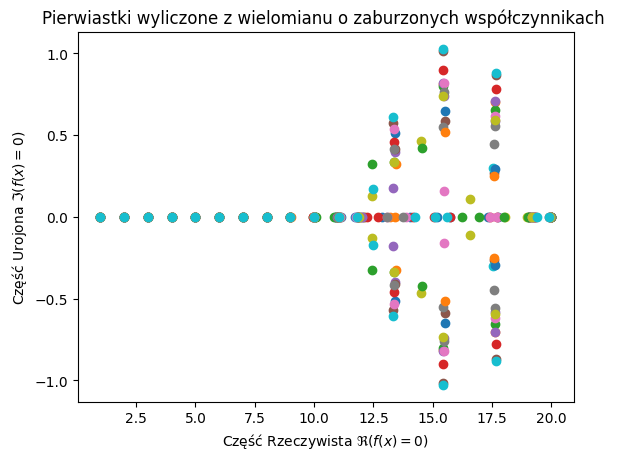

In [9]:
# ===== Twoja implementacja tutaj =====
#  Punkt 1
r1 = np.array([1.0, 2.0, 3.0])
r2 = np.array([i for i in range(1, 21)])

coofcients_1 = np.polynomial.polynomial.polyfromroots(r1)
coofcients_2 = np.polynomial.polynomial.polyfromroots(r2)
print("Współczynniki wielomianu z zadanymi pierwiastkami (punkt 1):")
print("Dla r1:", coofcients_1)
print("Dla r2:", coofcients_2)

# Punkt 2

# implementacja funkcji roots_20 znajduje się w pliku main.py

# Punkt 3
fig, ax = plt.subplots()
coofcients_dist = coofcients_2
for i in range(20):
    poly_new = main.roots_20(coofcients_2)
    coofcients_dist = poly_new[0]
    ax.plot(np.real(poly_new[1]), np.imag(poly_new[1]), 'o')
    ax.set(title='Pierwiastki wyliczone z wielomianu o zaburzonych współczynnikach ',
    xlabel='Część Rzeczywista $\Re(f(x)=0)$',
    ylabel='Część Urojona $\Im(f(x)=0)$')
    ax.grid()




Z otrzymanego wykresu wynika że najlepiej uwarunkowane sa pierwiastki do 1 do 11 oraz 18,19,20 jako że zasadzie nie zmieniaja one swojego położenia wraz z kolejnymi  iteracjami. Najgorzej uwarunkowany jest pierwiastek 15 i 16 jako że na nich sa największe wahania.

---

### **Zadanie 2.**

Na podstawie wiedzy z wykładu wiadomo, że wartości własne macierzy kwadratowej są pierwiastkami wielomianu charakterystycznego tej macierzy oraz, że każdy wielomian posiada swoją macierz stowarzyszoną (macierz Frobeniusa). Wynika z tego, że **poszukiwanie pierwiastków wielomianu jest równoważne poszukiwaniu wartości własnych macierzy stowarzyszonej**.

<br>

Dany jest wielomian:
$$
w_3(x) = (x-1)^8
$$ 

Należy wyznaczyć numerycznie jego miejsca zerowe na różne sposoby i porównać otrzymane wyniki z wartościami analitycznymi.

**Punkt 1.**

Przygotowanie macierzy stowarzyszonej.

1. Zaiplementuj funkcję *`frob_a()`* tworzącą [macierz Frobeniusa](https://en.wikipedia.org/wiki/Companion_matrix) dla zadanego wektora współczynników wielomianu.

2. Wyznacz macierz Frobeniusa $\mathbf{F_{w_3}}$ dla wielomianu $w_3(x)$.

<br>

**Punkt 2.**

Wyznaczenie pierwiastków wielomianu.

1. Wyznacz wartości własne macierzy $\mathbf{F_{w_3}}$ za pomocą funkcji [`np.linalg.eigvals()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html).  

2. Dokonaj rozkładu Schura macierzy $\mathbf{F_{w_3}}$ i na tej podstawie wyznacz wartości własne macierzy $\mathbf{F_{w_3}}$. Użyj funkcji [`sp.linalg.schur()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.schur.html).

3. Wyznacz pierwiastki wielomianu $w_3(x)$ przy użyciu funkcji [`nppoly.polyroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyroots.html).

<br>

**Punkt 3.**

Zestawienie wyników.

1. Utwórz wykres typu *scatter plot* i wyrysuj na nim wartości pierwiastków wyznaczonych w **Punkcie 2.** oraz pierwiastki oblicznone analitycznie na płaszczyźnie zespolonej.

2. Opisz wnioski wynikające z wykresu.

coefficients: [  1.  -8.  28. -56.  70. -56.  28.  -8.   1.]
type: <class 'numpy.ndarray'>
dtype: float64
shape: (9,)
DEBUG frob_a: type = <class 'numpy.ndarray'> ndim = 1 size = 9


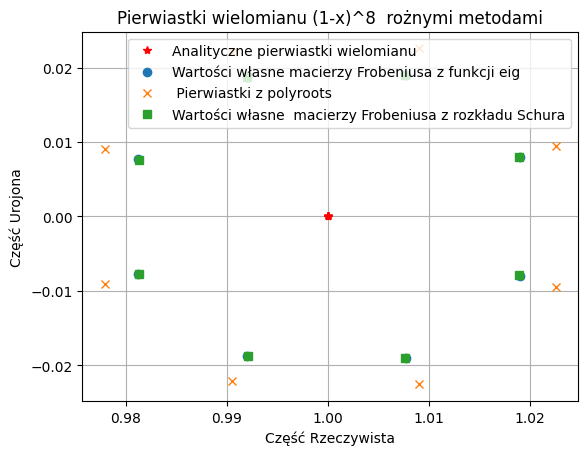

In [10]:
# ===== Twoja implementacja tutaj =====

# analitycznie mamy ośmiokrotny pierwiastek w_0 = 1

# Punkt 1 : implementacja funkcji frob_a() znajduje się w pliku main.py

roots_anal = np.array([1.0 for _ in range(8)])
coefficients = np.polynomial.polynomial.polyfromroots(roots_anal)
print("coefficients:", coefficients)
print("type:", type(coefficients))
print("dtype:", coefficients.dtype)
print("shape:", coefficients.shape)
F = main.frob_a(coefficients)

# Punkt 2 
eigenvalues, _ = np.linalg.eig(F)

A,P = sp.linalg.schur(F,output='complex')
shur_eigenvalues = np.diag(A)
roots = np.polynomial.polynomial.polyroots(coefficients)
# punkt 3
fig2, ax2 = plt.subplots()
ax2.plot(np.real(roots_anal), np.imag(roots_anal), 'r*', label='Analityczne pierwiastki wielomianu')
ax2.plot(np.real(eigenvalues), np.imag(eigenvalues), 'o', label='Wartości własne macierzy Frobeniusa z funkcji eig')
ax2.plot(np.real(roots), np.imag(roots), 'x', label=' Pierwiastki z polyroots')
ax2.plot(np.real(shur_eigenvalues), np.imag(shur_eigenvalues), 's', label='Wartości własne  macierzy Frobeniusa z rozkładu Schura')
ax2.set(title='Pierwiastki wielomianu (1-x)^8  rożnymi metodami',
        xlabel='Część Rzeczywista',
        ylabel='Część Urojona')
ax2.grid()
ax2.legend()


Z wynikowego wyrkesu wynika, że wyniki uzyskane za pomoca polyroots są rożne od wyników uzyskanych jako wartości własne macierzy Frobieniousa stowrzyszonej z podanym wielomianem. Ponadto zarówno funkcja np.linglang.eig daje takie same wartości własne macierzy Froubieniusa jako i rezultat rozkładu Shuro. Warto zawuważyć, że wszystke 3 metody daja rozwiązanie rożne od poprawnego rozwiązania analitycznego.

---

### **Zadanie 3.**

Dany jest wielomian:
$$
w_4(x) = 243x^7 - 486x^6 + 783x^5 - 990x^4 + 558x^3 - 28x^2 - 72x + 16
$$ 

1. Wyznacz numerycznie miejsca zerowe wielomianu $w_4(x)$ w sposób analogiczny jak w **Zadaniu 2.**

2. Wyrysuj na płaszczyźnie zespolonej wyznaczone pierwiastki oraz pierwiastki wyliczone analitycznie.

3. Porównaj otrzymane wyniki z rezulatatami otrzymanymi w **Zadaniu 2.**

>**Wskazówka:** Sprawdź poprawność wyznaczonego wektora współczynników z definicją w sekcji **Cel zajęć**.

DEBUG frob_a: type = <class 'numpy.ndarray'> ndim = 1 size = 8


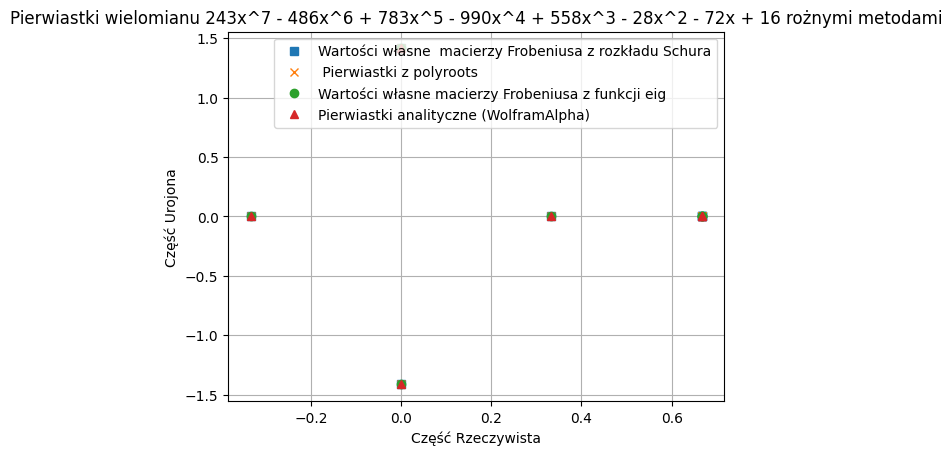

In [23]:
# ===== Twoja implementacja tutaj =====

coefficients = np.array([16.0 , -72.0, -28.0, 558.0, - 990.0, 783.0, - 486.0 , 243.0])
roots_anal = np.array([
    -1/3,
    1/3,
    2/3,
    2/3,
    2/3,
    -1j * np.sqrt(2),
    1j * np.sqrt(2)
])

F = main.frob_a(coefficients)
A,P = sp.linalg.schur(F,output='complex')
roots_shur= np.diag(A)
roots_poly = nppoly.polyroots(coefficients)
roots_frob_eig,_ = np.linalg.eig(F)

fig3, ax3 = plt.subplots()
ax3.plot(np.real(roots_shur), np.imag(roots_shur), 's', label='Wartości własne  macierzy Frobeniusa z rozkładu Schura')
ax3.plot(np.real(roots_poly), np.imag(roots_poly), 'x', label=' Pierwiastki z polyroots')
ax3.plot(np.real(roots_frob_eig), np.imag(roots_frob_eig), 'o', label='Wartości własne macierzy Frobeniusa z funkcji eig')
ax3.plot(np.real(roots_anal), np.imag(roots_anal), '^', label='Pierwiastki analityczne (WolframAlpha)')
ax3.set(title='Pierwiastki wielomianu 243x^7 - 486x^6 + 783x^5 - 990x^4 + 558x^3 - 28x^2 - 72x + 16 rożnymi metodami',
        xlabel='Część Rzeczywista',
        ylabel='Część Urojona')
ax3.grid()
ax3.legend()
plt.show()


Z wykresu wynika, że w zasadzie każda metoda daje taki sam wynik zgodny z analitycznym z dobrym przybliżeniem.

---

### **Zadanie 4.**

Zadanie polega na przeanalizowaniu w jaki sposób różne przekształcenia macierzy wpływają na pojawianie się błędów numerycznych.

W celu przeprowadzenia analizy skonstruuj trzy macierze diagonalne $\mathbf{A}_n$ dla $n = \{10,20,30\}$. Współczynniki macierzy powinny być zdefiniowane jako $a_{ii} = 2^i$ dla $i = \{1,2,...,n\}$ (skorzystaj z funkcji [`np.diag()`](https://numpy.org/doc/stable/reference/generated/numpy.diag.html)).

**Punkt 1.**

1. Dla każdej z macierzy $\mathbf{A}_n$ oblicz wartości własne przy użyciu [`np.linalg.eigvals()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html) i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 2.**

1. Zdefiniuj funcję *`is_nonsingular()`* sprawdzającą czy zadana macierz nie jest singularna. 

2. Skonstruuj losowe niesingularne macierze wektorów własnych $\mathbf{P}_n$, których wartości współczynników są liczbami całkowitymi z zakresu $(0,100)$. Na podstawie macierzy $\mathbf{A}_n$ i $\mathbf{P}_n$ oblicz macierze $\mathbf{B}_n$ postaci: 
$$
\mathbf{B}_n = \mathbf{P}_n\mathbf{A}_n\mathbf{P}_{n}^{-1}
$$ 

3. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{B}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

>**Wskazówka:** Niesingularność macierzy $\mathbf{P}_n$ można zapewnić generując je w pętli, w której warunkiem stopu będzie wynik funkcji zaimplementowanej w **Podpunkcie 1.**

<br>

**Punkt 3.**

1. Bazując na macierzach $\mathbf{P}_n$ wygeneruj macierze ortogonalne $\mathbf{Q}_n$ (można do tego użyć rozkładu QR). Na podstawie macierzy $\mathbf{A}_n$ i $\mathbf{Q}_n$ oblicz macierze $\mathbf{C}_n$ postaci:
$$
\mathbf{C}_n = \mathbf{Q}_n\mathbf{A}_n\mathbf{Q}_{n}^{-1}
$$

2. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{C}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 4.**

1. Bazując na analitycznych wartościach własnych dla wielomianów charakterystycznych macierzy $\mathbf{A}_n$ wygeneruj macierze Frobeniusa $\mathbf{F}_n$ korzystając z funkcji zaimplementowanej w **Zadaniu 2.** 

2. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{F}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 5.**

Porównaj wyniki otrzymane we wszystkich punktach. Opisz z czego wynikają powstałe błędy obliczeń.

In [ ]:
# ===== Twoja implementacja tutaj =====


ns = np.asarray([10, 20,30])

# Listy na błędy do końcowego wypisywania
max_error_A, mean_error_A = [], []
max_error_B, mean_error_B = [], []
max_error_C, mean_error_C = [], []
max_error_F, mean_error_F = [], []


for n in ns:
    # Wartości własne analityczne: 2^1, 2^2, ..., 2^n
    analytical_eigvals = np.sort(np.asarray([2.0 ** x for x in range(1, n+1)]))
    
    # --- Punkt 
    A_n = np.diag(analytical_eigvals)
    eig_A = np.sort(np.linalg.eigvals(A_n))
    
    err_A = np.abs(analytical_eigvals - eig_A)
    max_error_A.append(np.max(err_A))
    mean_error_A.append(np.mean(err_A))

    check = False
    while not check:
          P_n = np.diag(np.random.randint(0,100,(n)))
          check = main.is_nonsingular(P_n)
            
    P_inv = np.linalg.inv(P_n)
    B_n = P_n @ A_n @ P_inv
    eig_B = np.sort(np.linalg.eigvals(B_n))
    

    if np.iscomplexobj(eig_B):
         eig_B = np.sort_complex(eig_B)
         eig_B = np.sort(eig_B.real) 
    else:
         eig_B = np.sort(eig_B)

    err_B = np.abs(analytical_eigvals - eig_B)
    max_error_B.append(np.max(err_B))
    mean_error_B.append(np.mean(err_B))

    Q_n, R_n = np.linalg.qr(P_n) 
    C_n = Q_n @ A_n @ Q_n.T
    eig_C = np.sort(np.linalg.eigvals(C_n))
    
    if np.iscomplexobj(eig_C): eig_C = np.sort(eig_C.real)
    
    err_C = np.abs(analytical_eigvals - eig_C)
    max_error_C.append(np.max(err_C))
    mean_error_C.append(np.mean(err_C))

    poly_coeffs = np.poly(analytical_eigvals)
    F_n = main.frob_a(poly_coeffs)
    
    eig_F = np.linalg.eigvals(F_n)
    
    eig_F = np.sort(np.abs(eig_F)) 
    
    err_F = np.abs(analytical_eigvals - eig_F)
    max_error_F.append(np.max(err_F))
    mean_error_F.append(np.mean(err_F))

n_values = ns 
for i, n in enumerate(n_values):
    print(f"Dla n = {n}:")
    print(f"   {'Macierz':<18} {'Błąd maksymalny':<18} {'Błąd średni':<18}")
    print(f"   {'-'*55}")
    print(f"   {'A_' + str(n) + ' (diag)':<18} {max_error_A[i]:<18.2e} {mean_error_A[i]:<18.2e}")
    print(f"   {'B_' + str(n) + ' (P*A*P^-1)':<18} {max_error_B[i]:<18.2e} {mean_error_B[i]:<18.2e}")
    print(f"   {'C_' + str(n) + ' (Q*A*Q^T)':<18} {max_error_C[i]:<18.2e} {mean_error_C[i]:<18.2e}")
    print(f"   {'F_' + str(n) + ' (Frobenius)':<18} {max_error_F[i]:<18.2e} {mean_error_F[i]:<18.2e}\n")

UWAGA !!! Wbrew treści polecenia wygerowano P jako macierz losową,ale diagonalna zamiast gęstej, ponieważ realizujać treść polecania otrzymujemy macierz A z elementami nawet rzędu 2 do 30 co jest już bardzo, bardzo dużą liczbą, jak i zupełenie gęste odwracanie, rozkładnie itd macierzy 30 na 30  otrzymanej przez mnożenie z gęsto macierzą o losowych elementach, co sie liczy wiele minut.
Powstałe błedy wynikaja głównie z zaokrągleń , których bład się propaguję.

**Przykładowa forma zestawienia wyników:**
```python
for i, n in enumerate(n_values):
    print(f"   {'Macierz':<18} {'Błąd maksymalny':<18} {'Błąd średni':<18}")
    print(f"   {'-'*55}")
    print(f"   {'A_' + str(n) + ' (diag)':<18} {max_error_A[i]:<18.2e} {mean_error_A[i]:<18.2e}")
    print(f"   {'B_' + str(n) + ' (P*A*P^-1)':<18} {max_error_B[i]:<18.2e} {mean_error_B[i]:<18.2e}")
    print(f"   {'C_' + str(n) + ' (Q*A*Q^T)':<18} {max_error_C[i]:<18.2e} {mean_error_C[i]:<18.2e}")
    print(f"   {'F_' + str(n) + ' (Frobenius)':<18} {max_error_F[i]:<18.2e} {mean_error_F[i]:<18.2e}\n")
```

**Rezultat:**
```md
   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_10 (diag)        0.00e+00           0.00e+00          
   B_10 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_10 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_10 (Frobenius)   0.00e+00           0.00e+00          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_20 (diag)        0.00e+00           0.00e+00          
   B_20 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_20 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_20 (Frobenius)   0.00e+00           0.00e+00          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_30 (diag)        0.00e+00           0.00e+00          
   B_30 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_30 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_30 (Frobenius)   0.00e+00           0.00e+00
```

---

**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)